# Rep. 4. Checkpoint 5. Exóticas: Asiáticas y con Barrera

**Instrucciones**

Integra el código visto en clase en un notebook y contesta las preguntas con base en lo que observas

Dayanni Godoy

Eduardo Veytia 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
# Parámetros

S0 = 670
K = 680
r = 0.04
sigma = 0.17
N = 30          # numero de días
T = N/365       # tiempo al venc.
M = 10000       # numero de simulaciones
dt = T/N

Z = np.random.standard_normal((M,N))

retornos = (r - 0.5 * sigma ** 2) * dt + sigma * np.sqrt(dt) * Z

S_paths = S0 * np.exp(np.cumsum(retornos, axis = 1))
S_paths = np.insert(S_paths, 0, S0, axis = 1)

# vector de precios al vencimiento
ST = S_paths[:,-1]
# vector de precios promedio de fluctuacion del subyacente
S_media = S_paths.mean(axis=1)

europea = np.exp(-r * T) * np.maximum(ST - K, 0)
asiatica = np.exp(-r * T) * np.maximum(S_media - K, 0)

# analítica Black Scholes
d1 = (np.log(S0 / K) + (r + 0.5 * sigma **2) * T / sigma * np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)
bs_call = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

print("Precio Asiatica:",asiatica.mean())
print("Precio Europea:",europea.mean())
print("Precio Black Scholes:",bs_call)


Precio Asiatica: 4.029685760597774
Precio Europea: 9.89593588885521
Precio Black Scholes: 9.308744964731545


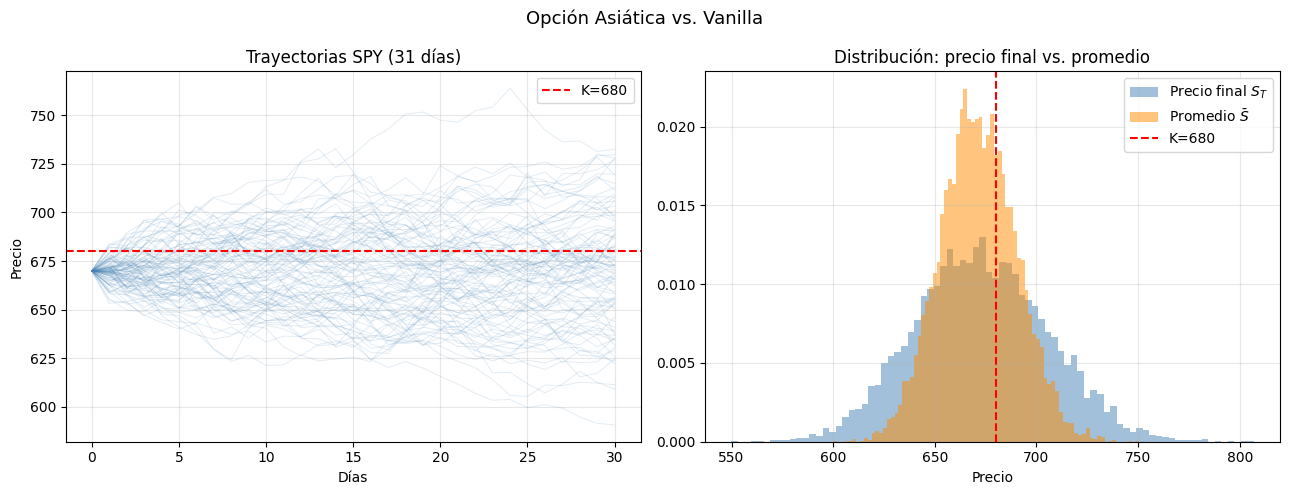

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Trayectorias con el promedio marcado
for i in range(100):
    axes[0].plot(S_paths[i], alpha=0.15, linewidth=0.7, color='steelblue')
axes[0].axhline(K, color='red', linestyle='--', linewidth=1.5, label=f'K={K}')
axes[0].set_title('Trayectorias SPY (31 días)')
axes[0].set_xlabel('Días')
axes[0].set_ylabel('Precio')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribución: precio final vs. promedio
axes[1].hist(ST,      bins=80, density=True, alpha=0.5,
             color='steelblue', label='Precio final $S_T$')
axes[1].hist(S_media, bins=80, density=True, alpha=0.5,
             color='darkorange', label='Promedio $\\bar{S}$')
axes[1].axvline(K, color='red', linestyle='--', label=f'K={K}')
axes[1].set_title('Distribución: precio final vs. promedio')
axes[1].set_xlabel('Precio')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Opción Asiática vs. Vanilla', fontsize=13)
plt.tight_layout()
plt.show()

In [3]:
B_up = 710

S_max = S_paths.max(axis=1)


# up and out
activa_up_and_out = (S_max < B_up)
call_up_and_out = np.exp(-r * T) * np.maximum(ST - K, 0) * activa_up_and_out

# up and out
activa_up_and_in = (S_max > B_up)
call_up_and_in = np.exp(-r * T) * np.maximum(ST - K, 0) * activa_up_and_in

print("up and out: ", call_up_and_out.mean())
print("up and in: ", call_up_and_in.mean())
print("europea", europea.mean())
print("comprobacion", call_up_and_out.mean() + call_up_and_in.mean()  )

up and out:  2.2872905818375475
up and in:  7.608645307017662
europea 9.89593588885521
comprobacion 9.89593588885521


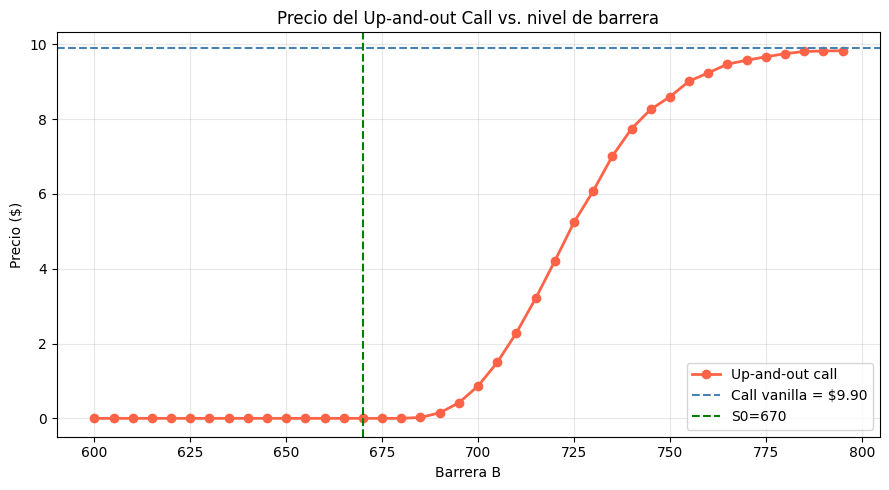

In [4]:
B_range = np.arange(600, 800, 5)   # barreras superiores
precios_uao = []

for b in B_range:
    s_max_b = S_paths.max(axis=1)
    precio  = np.exp(-r*T) * np.maximum(ST - K, 0) * (s_max_b < b)
    precios_uao.append(precio.mean())

plt.figure(figsize=(9, 5))
plt.plot(B_range, precios_uao, color='tomato', linewidth=2, marker='o',
         label='Up-and-out call')
plt.axhline(europea.mean(), color='steelblue', linestyle='--',
            linewidth=1.5, label=f'Call vanilla = ${europea.mean():.2f}')
plt.axvline(S0, color='green', linestyle='--', label=f'S0={S0}')
plt.xlabel('Barrera B')
plt.ylabel('Precio ($)')
plt.title('Precio del Up-and-out Call vs. nivel de barrera')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Preguntas
- **La opción asiática es más barata que la vanilla. ¿Siempre es así? ¿Puedes pensar en algún caso donde fueran igual de caras?**

Generalmente sí, porque promediar los precios reduce la volatilidad y a menor volatilidad, menor precio de la opción. Serían igual de caras en un escenario teórico donde la volatilidad del activo fuera exactamente cero.

- **Verificaste que up-and-in + up-and-out = vanilla. ¿Qué implica eso para el pricing? ¿Puedes usarlo para encontrar el precio de una si conoces la otra?**

Implica que existe una paridad in-out por la cual una opción europea estándar se puede replicar con dos de barrera. Sí se puede usar para pricing: si conoces el precio de la vanilla y de la up-and-out, simplemente calculas la up-and-in por diferencia. In = Vanilla - Out

- **Si la barrera B está muy cerca de S0, el up-and-out call casi no vale nada. ¿Por qué? ¿Y si la barrera está muy lejos?**

Si está muy cerca, la probabilidad de que el precio toque la barrera y la opción se anule es altísima, quitándole todo el valor. Si está muy lejos, es improbable que la toque, por lo que se comporta prácticamente como una call vanilla.

- **¿Por qué Monte Carlo es especialmente apropiado para opciones exóticas? ¿Cuál es su limitación principal vs. soluciones analíticas?**

Es ideal porque permite modelar fácilmente opciones que dependen de la trayectoria del precio, como las asiáticas o de barrera. Su principal limitación es el alto costo computacional y que arroja una aproximación con cierto margen de error, no un valor exacto.
